# Simulation-based inference

**Bayesian inference** is a framework to solve an **inverse problem** by *treating parameters as random variables* and *quantifying the uncertainty through probability distributions*.

Consider a model parameterized by $\Theta \in \mathbb{R}^{\rm D_{\Theta}}$ that generates observable data $\mathbf{x} \in \mathbb{R}^{\rm D_{\mathbf{x}}}$. A bayesian inference is the question of "What is the probability a model is true given an observable dataset?"
$$
p(\Theta \, | \, \mathbf{x}) = \dfrac{p(\mathbf{x} \, | \, \Theta) p(\Theta)}{p(\mathbf{x})}
$$ where
- $p(\Theta)$ is the prior knowledge about parameters. 
- $p(\mathbf{x}) = \int p(\mathbf{x} \, | \, \Theta) p (\Theta) d \Theta$ is the evidence (marginal likelihood), normalizing the posterior.



However, the practical implementation is complex. In some realistic scientific problems involving **complex models** or **high-dimensional parameters spaces**, direct computation of some quantities (prior, likelihood, evidence) can become **intractable** or computationally challenging.  

The posterior $p(\Theta \, | \, \mathbf{x})$ is a priori **unknown** (its shape can be multimodal, heavy-tailead or live in a complex regions of parameter space) and **must be discovered through computation**.

## Computational strategies
### 1. Traditional sampling-based method
**a. Simple methods**
- Markov Chain Monte Carlo (MCMC)
- Nested Sampling (NS)
  
*Properties*
- Require **evaluation of likelihood** $p(x_0 \, | \, \Theta)$ for an observable $x_0$.
- Construct **sampling schemes** that **avoid explicit evidence integral computation**. (e.g evaluating likelihood ratio in MCMC)

**b. More sophisticated methods**
- Hamiltonian Monte Carlo (HMC)
- Variational Inference (VI)

*Properties*
- Require gradient $\nabla_{\Theta} \log p(x_0 \, | \, \Theta)$ to efficiently navigate through high-dimensional parameter space.

### 2. Simulation-based inference
SBI do **not** require likelihood evalution but require the **generation of joint samples** 
$$(\mathbf{x}, \Theta) \sim p(\mathbf{x}, \, \Theta)$$
by sampling parameters from prior and running **forward simulator**.

- **Terminology:** simulation-based inference, likelihood-free inference, implicit likelihood inference (they are the same!)

- SBI is more applicable than traditional methods when the **likelihoods** are only **implicitly defined** through **forward complex simulator** (marginalization over latent variables are intractable). The **trade-off** is you need to **train a flexible model** to **approximate** the **posterior** from **simulated data**.

## Approximate Bayesian Computation
- **History:** Donald Rubin, 1980s. He tried to find a computational method that could handle models beyond analytically tractable likelihoods. 

ABC is a rejection sampling algorithm, given a prior $\Theta \sim p(\Theta)$, the proposed sample $\mathbf{x} \sim p(\mathbf{x} \, | \, \Theta)$ from forward model are compared to target observed data $\mathbf{x_0}$:
$$
d(\mathbf{x}, \mathbf{x_0}) = | s (\mathbf{x}) - s(\mathbf{x_0})| 
$$
- $s$ is a low-dimensional summary statistics.
- $d$ is the simplest 1D metric.

Samples from the approximate posterior are drawn with rejection sampling using an acceptance tolerance $\epsilon$ such that
$$
d(\mathbf{x}, \mathbf{x_0}) < \epsilon
$$
So, the posterior
$$
p_{ABC}(\Theta \, | \, \mathbf{x}) = \dfrac{\int_{d(\mathbf{x_0}, \mathbf{x})<\epsilon} d\mathbf{x} \, p(\mathbf{x \, | \, \Theta}) p(\Theta)}{\int_{d(\mathbf{x_0}, \mathbf{x})<\epsilon} d\mathbf{x} \, p(\mathbf{x})} 
$$
guarantees to converge to the true one for sufficiently informative summary statistics $s(\mathbf{x})$ and for $\epsilon \to 0$. 

**Recipe**:
- **Define a prior $p(\Theta)$:** your belief about plausible values of parameters.
- **Simulator**: A forward model to generate data given parameters $\Theta$.
- **Distance metric** $d$: How close simulated data $x'$ to real data $x$ (Euclidean, Maximum absolute difference, summary statistics distance)
- **Threshold** $\epsilon$: small, positive number define how close simulated data must be to be accepted.

**Example**: Let's try to infer the mean $\mu$ of a Gaussian distribution with known variance

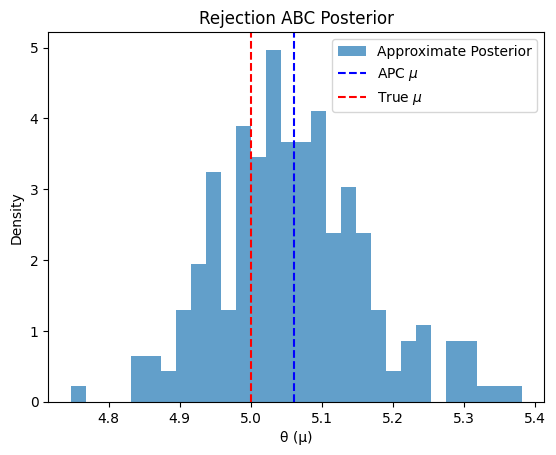

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Observed data (from an 'unknown' true mean)
mu_true = 5
observed_data = np.random.normal(loc=mu_true, scale=1.0, size=100)

# Prior: Uniform between 0 and 10
def sample_prior():
    return np.random.uniform(0, 10)

# Simulator: given mu, generate synthetic data
def simulate(mu):
    return np.random.normal(loc=mu, scale=1.0, size=100)

# Distance function: Euclidean distance between means
def distance(x_sim, x_obs):
    return np.abs(np.mean(x_sim) - np.mean(x_obs))

# Rejection ABC
accepted_thetas = []
epsilon = 0.1  # the acceptance threshold
n_samples = 10000  # number of prior samples

for _ in range(n_samples):
    theta = sample_prior()
    x_sim = simulate(theta)
    d = distance(x_sim, observed_data)
    
    if d < epsilon:
        accepted_thetas.append(theta)
        
mu_apc = np.mean(accepted_thetas)
# Plotting the posterior
plt.hist(accepted_thetas, bins=30, density=True, alpha=0.7, label='Approximate Posterior')
plt.axvline(mu_apc, color='blue', linestyle='--', label='APC $\mu$')
plt.axvline(mu_true, color='red', linestyle='--', label='True $\mu$')
plt.xlabel('θ (μ)')
plt.ylabel('Density')
plt.legend()
plt.title('Rejection ABC Posterior')
plt.show()

### Limitation
Rejection ABC is very inefficient, particularly in high-dimensional spaces or when prior distribution is very different from posterior distribution. 
- Need to simulate enough samples to get a sufficient number of accepted samples.
- Distance calculations is impractical for high-dimensional or structured data (e.g. images).
- If $\epsilon$ too large, approximate is poor, but if $\epsilon$ too small, nearly all samples are rejected.

## Neural Simulation-Based Inference

- Development of neural network-based algorithms can help to overcome the curse of dimensionality

There are 3 main approaches based on Bayes's theorem:
- **Neural Posterior Estimation** (NPE)
- **Neural Likehood Estimation** (NLE)
- **Neural Ratio Estimation** (NRE)

### Neural Posterior Estimation
- The most straightforward method
- Introduce a density estimator $$q_\Phi^{\rm NPE}(\Theta \, | \, \mathbf{x})$$ parameterized through a **neural network** with weights $\Phi$.
- Train the estimator to approximate the posterior for parameters $\Theta$ given the data $\mathbf{x}$
$$
q_\Phi^{\rm NPE}(\Theta \, | \, \mathbf{x}) \approx p(\Theta \, | \, \mathbf{x})
$$
- To approximate, we need a distance measure, a common one is **Kullback-Leibler (KL) divergence**
$$
D_{KL} (p(x) \, || \, q(x)) = \int dx \, p(x) \ln \dfrac{p(x)}{q(x)}
$$

Forward KL D_KL(p||q) ≈ 0.3500
Reverse KL D_KL(q||p) ≈ 0.7126


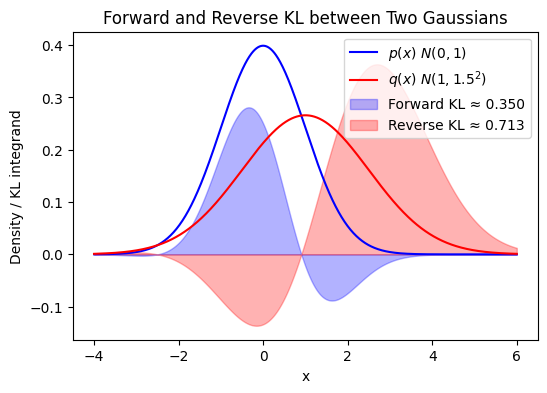

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Define Gaussians ---
mu_p, sigma_p = 0.0, 1.0
mu_q, sigma_q = 1.0, 1.5

x = np.linspace(-4, 6, 1000)
dx = x[1] - x[0]

p = norm.pdf(x, mu_p, sigma_p)
q = norm.pdf(x, mu_q, sigma_q)

# --- Forward KL integrand: p(x) * log(p/q) ---
kl_forward_integrand = p * np.log(p / q)
kl_forward = np.sum(kl_forward_integrand) * dx

# --- Reverse KL integrand: q(x) * log(q/p) ---
kl_reverse_integrand = q * np.log(q / p)
kl_reverse = np.sum(kl_reverse_integrand) * dx

print(f"Forward KL D_KL(p||q) ≈ {kl_forward:.4f}")
print(f"Reverse KL D_KL(q||p) ≈ {kl_reverse:.4f}")

# --- Plot ---
plt.figure(figsize=(6,4))

# PDFs
plt.plot(x, p, label=r'$p(x) ~ N(0,1)$', color='blue')
plt.plot(x, q, label=r'$q(x) ~ N(1,1.5^2)$', color='red')

# Shade KL areas
plt.fill_between(x, 0, kl_forward_integrand, color='blue', alpha=0.3, label=f'Forward KL ≈ {kl_forward:.3f}')
plt.fill_between(x, 0, kl_reverse_integrand, color='red', alpha=0.3, label=f'Reverse KL ≈ {kl_reverse:.3f}')

plt.xlabel('x')
plt.ylabel('Density / KL integrand')
plt.title('Forward and Reverse KL between Two Gaussians')
plt.legend()
plt.show()

**Properties:**
- **Asymmetric**: $D_{KL} (p(x) \, || \, q(x)) \neq D_{KL} (q(x) \, || \, p(x))$
- If $q(x) = p(x)$, $D_{KL} = 0$.
- $D_{KL} \geq 0$

To train an NPE estimator, minimize a forward KL divergence 
$$
D_{KL}(p \, || \, q_\Theta^{\rm NPE}) = \int d \Theta \, p (\Theta \, | \, \mathbf{x}) \ln \dfrac{p(\Theta \, | \, \mathbf{x})}{q_{\Theta}^{\rm NPE}(\Theta \, | \, \mathbf{x})} = \mathbb{E}_{\Theta \sim p(\Theta \, | \, \mathbf{x})} \left[ \ln \dfrac{p(\Theta \, | \, \mathbf{x})}{q_{\Theta}^{\rm NPE}(\Theta \, | \, \mathbf{x})} \right]
$$

The expectation value is taken from the true posterior distribution, the expression can not be evaluated. To overcome this limitation, we can average over simulation data $\mathbf{x} \sim p(\mathbf{x})$:
\begin{aligned}
\underset{\boldsymbol{x} \sim p(\boldsymbol{x})}{\mathbb{E}}\left[D_{\mathrm{KL}}\left(p \| q_{\Phi}^{\mathrm{NPE}}\right)\right] & =\underset{\boldsymbol{x}, \Theta \sim p(\boldsymbol{x}, \Theta)}{\mathbb{E}}\left[\ln \frac{p(\Theta \mid \boldsymbol{x})}{q_{\Phi}^{\mathrm{NPE}}(\Theta \mid \boldsymbol{x})}\right] \\
& =\underbrace{-\underset{\boldsymbol{x}, \Theta \sim p(\boldsymbol{x}, \Theta)}{\mathbb{E}} \ln q_{\Phi}^{\mathrm{NPE}}(\Theta \mid \boldsymbol{x})}_{\text {expected entropy }}+\underbrace{\underset{\boldsymbol{x}, \Theta \sim p(\boldsymbol{x}, \Theta)}{\mathbb{E}} \ln p(\Theta \mid \boldsymbol{x})}_{\text {constant w.r.t. } \Phi} .
\end{aligned}

The loss is the expected forward KL, decomposed into two terms. The second term is constant with respect to the weights $\Phi$, so only the first term contribute to the loss function. The first term is called "expected entropy" because the mathematical form is similar to negative entropy $-H[q]$, measuring how well the approximate posterior $q$ assigns probability mass to the regions where the true distribution $p$ actually place $(\mathbf{x}, \Phi)$ pairs.

NPE loss function is the expected value over simulation of negative log-probability estimator
$$
\mathcal{L}^{\rm NPE}[\Phi] = - \underset{\mathbf{x}, \Phi \sim p(\mathbf{x}, \Phi)}{\mathbb{E}} \ln q_{\Phi}^{\rm NPE} (\Phi \, | \, \mathbf{x})
$$

#### Density Estimator

The density estimator need to satisfy probability density properties, such as the normalization
$$
\int d \Theta q_\Phi^{\rm NPE} (\Theta \, | \, \mathbf{x}) = 1
$$
which can be enforced by parameterizing $q^{\rm NPE}_\Phi$ with architectures specifically designed for density estimation.

**Normalizing flow**: are a family of generative models with tractable distributions where both sampling and density evaluation can be efficient and exact. NF is a transformation from a simple probability distribution (e.g. normal distribution) to a more complex distribution by a sequence of *invertible* and *differentiable* mappings.

Given a base distribution, $z_0 \sim p(z_0)$, define a series of forward mappings $f_k$ with $k = 1,...,K$ such that
$$
z_k = f_{k}(z_{k-1})
$$
New density can be sampled from the initial distribution applied the chain of $K$ transformation
$$
x= z_k = f_k \circ ... \circ f_1 (z_0)
$$

The density of a sample can be evaluated by transforming back to original simple distribution. We need to account for volume changed in the inversed transformation using Jacobians for each transformation.
$$
\log p(x) = \log p(z_0) - \sum_{k = 1}^K \log | \det J_k(z_{k-1})|
$$

To train a normalizing flow, the trainable parameters $\Phi$ consists of both the parameters of the base distribution $p(z_0)$ and $K$ transformations. Parameters are optimized via gradient descent by minimizing the loss function.

**Autoregressive Flow**: balances expressiveness with computational tractability. 
- *Masked Autoregressive Flow* (MAF): decomposes the transformation into a sequence of univariate conditional transformations, making Jacobians triangular, allowing $\mathcal{O}(D)$ density evaluation. But sampling still require $\mathcal{O}(D^2)$ operations.
- *Inverse Autoregressive Flow* (IAF): reverses this trade-off, enabling fast sampling but slower density evaluation. 
- *Neural Spline Flows* (NSF): use monotonic splines as the transformation functions, increasing expressiveness
through piecewise transformations. 

#### Variational Inference


VI allows the approximation of extremely high-dimensional Bayesian posteriors with simple proposal distribution by solving an optimization problem. 

The proposal distribution is the variational posterior $$p^{\rm VI}_\Phi(\Theta \, | \, \mathbf{x})$$
To approximate the true posterior, VI optimize the *reverse* KL divergence
$$
D_{\mathrm{KL}}\left(q_{\Phi}^{\mathrm{VI}} \| p\right)=\int \mathrm{d} \Theta q_{\Phi}^{\mathrm{VI}}\left(\Theta \mid \boldsymbol{x}_0\right) \ln \left(\frac{q_{\Phi}^{\mathrm{VI}}\left(\Theta \mid \boldsymbol{x}_0\right)}{p\left(\Theta \mid \boldsymbol{x}_0\right)}\right)=\underset{\Theta \sim q_{\Phi}^{\mathrm{VI}}\left(\Theta \mid \boldsymbol{x}_0\right)}{\mathbb{E}}\left[\mathrm{ln} \frac{q_{\Phi}^{\mathrm{VI}}\left(\Theta \mid \boldsymbol{x}_0\right)}{p\left(\Theta \mid \boldsymbol{x}_o\right)}\right]
$$

Using Bayes's theorem, we obtain
$$
\begin{aligned}
D_{\mathrm{KL}}\left(q_{\Phi}^{\mathrm{VI}} \| p\right) & =\underset{\Theta \sim q_{\Phi}^{\mathrm{VI}}\left(\Theta \mid \boldsymbol{x}_o\right)}{\mathbb{E}}\left[\ln \frac{q_{\Phi}^{\mathrm{VI}}\left(\Theta \mid \boldsymbol{x}_o\right)}{p\left(\Theta \mid \boldsymbol{x}_o\right)}\right] \\
& =\underbrace{\underset{\Theta \sim q_{\Phi}^{\mathrm{VI}}\left(\Theta \mid \boldsymbol{x}_o\right)}{\mathbb{E}}\left[\ln \frac{q_{\Phi}^{\mathrm{VI}}\left(\Theta \mid \boldsymbol{x}_o\right)}{p\left(\boldsymbol{x}_0 \mid \Theta\right) p(\Theta)}\right]}_{\equiv-\mathrm{ELBO}}+\underbrace{\ln p\left(\boldsymbol{x}_0\right)}_{\text {constant w.r.t. } \Phi},
\end{aligned}
$$

The evidence lower bound (ELBO) comes from the fact that $D_{KL} \geq 0$, so 
$$
\rm ELBO \leq \ln p(x_0)
$$
Maximize the ELBO provides the lower bound for log-evidence, which exactly when the variational posterior matches the true posterior.

So, minimizing the reverse KL divergence is maximizing the ELBO, the VI loss is
$$
\mathcal{L}^{\mathrm{VI}}[\Phi]=\mathrm{ELBO} \equiv \underset{\Theta \sim q_{\Phi}^{\mathrm{VI}}\left(\Theta \mid \boldsymbol{x}_0\right)}{\mathbb{E}}\left[\ln p\left(\boldsymbol{x}_0, \Theta\right)-\ln q_{\Phi}^{\mathrm{VI}}\left(\Theta \mid \boldsymbol{x}_0\right)\right]
$$

The difference between VI and NPE are
- NPE trains for an amortized inference network $q^{\rm NPE}_\Phi$ to handle any observable $\mathbf{x}$, VI optimizes the variational posterior $q^{\rm VI}_\Phi$ specifically for a single observed dataset $x_0$. Therefore, VI need to be re-run for each new observation, but NPE does not. 
- NPE draws parameters from prior $p(\Theta)$ while VI draws from variational posterior $q_{\Phi}^{\rm VI}(\Theta \, | \, \mathbf{x_0})$. So, for VI, samples increasingly focus on regions of high data likelihood.
- For VI, posterior must cover all parameters that the likelihood model is conditioned on, and omitting correlation gives lower bound on parameter uncertainties. On the other hand, for NPE, if we substitute $q_{\Phi}^{\rm NPE}$ with a low dimensional marginal, we automatically get marginal posterior estimates, without performing integral explicitly. The ability to directly perform marginal inference is one of the most powerful features of SBI.

### Neural Likelihood Estimation

Another choice is to train for a likelihood estimator
$$
q_\Phi^{\rm NLE}(\mathbf{x}\, | \, \Theta) \approx p(\mathbf{x}\, | \, \Theta)
$$
The loss function will be
$$
\mathcal{L}^{\mathrm{NLE}}[\Phi]=-\underset{\boldsymbol{x}, \Theta \sim p(\boldsymbol{x}, \Theta)}{\mathbb{E}} \ln q_{\Phi}^{\mathrm{NLE}}(\boldsymbol{x} \mid \Theta)
$$
A specialized network architecture like *normalizing flow* can also be used in this case.

The choice between NPE and NLE depends on the dimensionality of the data and parameter space, as well as the complexity of the likelihood or posterior. Neural networks are easier to train from higher dimensional data to lower dimensional output. If the data is high-dimensional, NPE is a more suitable choice. On the other hand, high-dimensional posterior inference, NLE can outperform NPE, given a good data summaries.

### Neural Ratio Estimation

## Data Compression

It is very challenging for mapping from high-dimensional data to low-dimensional parameters. Therefore, **careful choice of summary statistics is necessary**.

There are three main approaches:
- Hand-crafted summary statistics from domain knowledge.
- Statistical compression that maximize Fisher information.
- End-to-end neural compression trained jointly with the density estimator or classifier.

### Summary statistics
The simplest approach is to apply domain-specific summary statistics before passing the compressed
data to neural SBI algorithms. In some cases, domain knowledge identifies summary statistics that
are provably sufficient or nearly optimal for inference, preserving all relevant information (known
as sufficient statistics). However, for complex simulators, hand-crafted summaries may not be
sufficient statistics and could discard important information. As a result, the trade-off is between
the reliability and interpretability of well-understood summaries (even if not sufficient) versus the
potential for capturing additional information through more flexible approaches.

- For the case of Adriaan. et al, they use NILC as the summary statistics for SBI.

###  Information-Theoretic Compression

- **Fisher information matrix**: we can find directions in data space that are most sensitive to parameters. (only works well for Gaussian models).
- **Score compression**: it is a two-step procedure, first extract features, second approximate the score function
$$
t(x) = \nabla_\Theta \log \mathcal{L} (x \, | \, \Theta)
$$ 
this gives optimal summaries asymptotically even if the data is non-Gaussian or the covariance depends on parameters.

### End-to-End Neural Compression

Rather than compress the data before inference, compression and inference can be done simultaneously in a unified network. 

## Sequential Inference
Active learning improves sample efficiency by using **acquired knowledge** to **guide where the simulator to run next**. The idea is to iteratively simulate at parameter points expected to maximize information gain, **updating our knowledge after each simulation to inform the next one**. In Bayesian inference, this means  